In [37]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt # make sure inline is intalled in your matplotlib version

import pingouin as pg

# Use the inline magic command
# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = os.path.join(parent_dir, 'dfs')


In [33]:
# Load the subject list from previous analyses:
subject_ids = pd.read_csv(os.path.join(data_path, 'SSP_participants_3nights.csv'))
print(f"Number of subjects: {len(subject_ids)}")

Number of subjects: 136


In [34]:
# Load questionnaires data:
Quest_data = pd.read_csv(os.path.join(data_path, 'df_questionnaires.csv'))

# Load Dreem and Pops data:
df_dreem = pd.read_csv(os.path.join(data_path, 'df_dreem_clean.csv'))
df_yasa = pd.read_csv(os.path.join(data_path, 'df_yasa_clean.csv'))

print(f"Questionnaires data: {len(Quest_data)} rows")
print(f"Dreem data: {len(df_dreem)} rows")
print(f"Yasa data: {len(df_yasa)} rows")

Questionnaires data: 200 rows
Dreem data: 2408 rows
Yasa data: 2271 rows


In [13]:
# Merge Dreem and Yasa data by subject ID and date:
df_dreem['date'] = pd.to_datetime(df_dreem['date'])
df_yasa['date'] = pd.to_datetime(df_yasa['date'])

# Merge the DataFrames on 'SPID' and 'date' with suffixes
merged_df = pd.merge(df_dreem, df_yasa, on=['SPID', 'date'], how='inner', suffixes=('_dreem', '_yasa'))

print(f"Merged data: {len(merged_df)} rows")

Merged data: 2202 rows


### Merge Dreem data with data from previous analysis

In [27]:
# Group by subject and filter out those with less than 3 nights/rows
subject_night_counts = merged_df['SPID'].value_counts()
subjects_to_keep = subject_night_counts[subject_night_counts >= 3].index

# Extract DreemPops_data containing only the subjects with 3 or more nights/rows with both device recordings:
DreemYasa_3nights = merged_df[merged_df['SPID'].isin(subjects_to_keep)]
print(f"Number of subjects with 3 or more nights/rows: {len(subjects_to_keep)}")
print(f"Number of recordings for these subjects: {len(DreemYasa_3nights)}")

# Extract overlapping data with the subjects used in previous analyses:
DreemYasa_3nights = DreemYasa_3nights[DreemYasa_3nights['SPID'].isin(subject_ids['SPID'])]
print(f"Number of Dreem-YASA overlapping subjects: {len(DreemYasa_3nights['SPID'].unique())}")
print(f"Number of recordings for Dreem-YASA overlapping subjects: {len(DreemYasa_3nights)}")

# Count number of ASD and Sib subjects in this dataset:
DreemYasa_3nights_ASD = DreemYasa_3nights[DreemYasa_3nights['user_type_dreem'] == 'ASD']
DreemYasa_3nights_Sib = DreemYasa_3nights[DreemYasa_3nights['user_type_dreem'] == 'NASD']

print(f"Number of ASD subjects: {len(DreemYasa_3nights_ASD['SPID'].unique())}")
print(f"Number of recordings for ASD subjects: {len(DreemYasa_3nights_ASD)}")
print(f"Number of NASD subjects: {len(DreemYasa_3nights_Sib['SPID'].unique())}")
print(f"Number of recordings for NASD subjects: {len(DreemYasa_3nights_Sib)}")

Number of subjects with 3 or more nights/rows: 184
Number of recordings for these subjects: 2187
Number of Dreem-YASA overlapping subjects: 136
Number of recordings for Dreem-YASA overlapping subjects: 1728
Number of ASD subjects: 69
Number of recordings for ASD subjects: 955
Number of NASD subjects: 67
Number of recordings for NASD subjects: 773


### Organize the data to allow correlation between sleep measures and questionnaire scores:

In [28]:
# Compute the average per subject of selected sleep measures:

DreemYasa_bysub = DreemYasa_3nights[['SPID','TST_dreem', 'WASO_dreem', 'SOL_dreem', 
                                     'SO_FromMidNight_dreem', 'FA_FromMidNight_dreem', 'WASO_yasa', 'TST_yasa',
                                     'SOL_yasa', 'SO_FromMidNight_yasa','FA_FromMidNight_yasa']].groupby('SPID').mean()

print(f"Number of subjects in DreemYasa_bysub: {len(DreemYasa_bysub)}")

# Merge sleep measures data with questionnaire data:
Combined_data_bysub = DreemYasa_bysub.merge(Quest_data, on='SPID', how='inner')

print(f"Number of subjects in Combined_data_bysub after merging with questionnaire data: {len(Combined_data_bysub)}")

Number of subjects in DreemYasa_bysub: 136
Number of subjects in Combined_data_bysub after merging with questionnaire data: 136


Create correlation and p-value matrices:

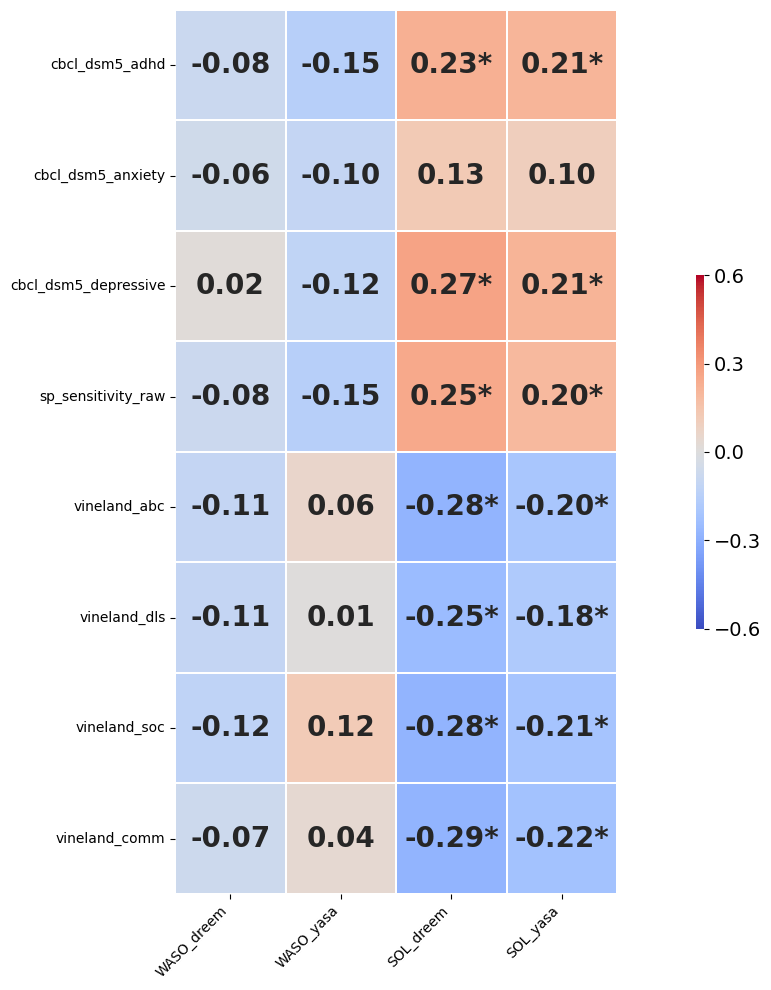

In [36]:
# Select measures to examine:

y_measures = ['WASO_dreem','WASO_yasa', 'SOL_dreem', 'SOL_yasa']


x_measures = ['cbcl_dsm5_adhd', 'cbcl_dsm5_anxiety', 'cbcl_dsm5_depressive', 
       'sp_sensitivity_raw', 'vineland_abc', 'vineland_dls', 'vineland_soc',
       'vineland_comm']

# Create two matrices to hold the correlation coefficients and their p values:
corr_matrix = pd.DataFrame(index=x_measures, columns=y_measures, dtype=float)
p_matrix = pd.DataFrame(index=x_measures, columns=y_measures, dtype=float)

# Now loop through pairs of variables and compute correlation and p-value
for x in x_measures:
       for y in y_measures:
              # Create a new data frame while removing everything except for x and y variables
              xy_data = Combined_data_bysub[[x, y]].dropna()
              corr, p_value = pearsonr(xy_data[x], xy_data[y])                    
              corr_matrix.loc[x, y] = corr
              p_matrix.loc[x, y] = p_value


# Create figure with results:
plt.figure(figsize=(16, 10))

# Create a mask for significant correlations - define p value
sig_mask = p_matrix <= 0.05

# Create annotation array
annot = np.empty_like(corr_matrix, dtype=object)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        annot[i,j] = f"{corr_matrix.iloc[i,j]:.2f}"
        if sig_mask.iloc[i,j]:
            annot[i,j] += '*'

# Use function from Seaborn package to create color matrix:
ax = sns.heatmap(corr_matrix, annot=annot, fmt='', cmap='coolwarm', vmin=-0.6, vmax=0.6, center=0, 
            linewidths=.1,annot_kws={'size': 20, 'weight':'bold'}, 
                    square=True, cbar_kws={'shrink': 0.4, 'aspect': 40} )

# Properties for color bar on right of figure
cbar = ax.collections[0].colorbar
# cbar.set_label('Correlation', fontsize=16)
cbar.ax.tick_params(labelsize=14)
cbar.set_ticks([-0.6, -0.3, 0, 0.3, 0.6])

plt.xticks(rotation=45, ha='right',fontsize = 10)
plt.yticks(rotation=0,fontsize = 10)
plt.tight_layout()
# plt.savefig(f'/mnt/home/mhacohen/ceph/weekly_report/{title}.png')
plt.show()
